<a href="https://colab.research.google.com/github/HaiderZahoorr/COMPUTER-VISION/blob/main/LAB_05/Lab05_HOG_Defect_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 05: HOG-Based Industrial Defect Detection and Classification
**Pipeline:** Image → Grayscale/Resize → HOG → Classifier (SVM / Random Forest) → Accept / Reject

Protocol (follows the skin-lesion comparative paper): one stratified 70/15/15 split, one seed, class-weighted learning, macro-averaged metrics, efficiency reporting, honest single-run caveat.

**Run the cells in order.**

## Step 0: Install and load the dataset
Upload the dataset zip from Kaggle (download it in your browser first). If a zip is already in `/content`, it is used automatically.

In [3]:
!pip -q install kagglehub scikit-image tabulate
import zipfile, glob, os

SLUG = "sovitrath/neu-steel-surface-defect-detect-trainvalid-split"

def count_images(path):
    return len([p for e in ("jpg", "jpeg", "png", "bmp")
                for p in glob.glob(path + "/**/*." + e, recursive=True)])

try:
    import kagglehub
    DATA = kagglehub.dataset_download(SLUG)
    print("Downloaded to:", DATA)
except Exception as e:
    print("Direct download failed:", str(e)[:150])
    print("Falling back to manual zip upload...")
    from google.colab import files
    zips = glob.glob("/content/*.zip")
    if not zips:
        files.upload()
        zips = glob.glob("/content/*.zip")
    print("Using:", zips[0])
    zipfile.ZipFile(zips[0]).extractall("/content/neu")
    DATA = "/content/neu"

print(count_images(DATA), "image files found")

Using Colab cache for faster access to the 'neu-steel-surface-defect-detect-trainvalid-split' dataset.
Downloaded to: /kaggle/input/neu-steel-surface-defect-detect-trainvalid-split
1800 image files found


## Step 1: Functions (load, preprocess, HOG, models, distortions, decision module)

In [4]:
import os, re, time, glob, itertools
import numpy as np, cv2, pandas as pd, matplotlib.pyplot as plt, joblib
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

SEED, IMG = 42, 128
OUT = "lab05_output"; os.makedirs(OUT, exist_ok=True)

# Task 1: load (label = filename prefix, e.g. crazing_12.jpg -> crazing)
def load_dataset(root):
    paths = [p for e in ("jpg","jpeg","png","bmp")
             for p in glob.glob(os.path.join(root, "**", f"*.{e}"), recursive=True)]
    X, y = [], []
    for p in sorted(paths):
        m = re.match(r"([A-Za-z\-_]+?)_?\d+", os.path.basename(p))
        label = m.group(1).strip("_").lower() if m else os.path.basename(os.path.dirname(p)).lower()
        im = cv2.imread(p)
        if im is None: continue
        X.append(im); y.append(label)
    return X, np.array(y)

# Tasks 2-3: resize + grayscale
def preprocess(im):
    g = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY) if im.ndim == 3 else im
    return cv2.resize(g, (IMG, IMG), interpolation=cv2.INTER_AREA)

# Task 4: HOG
def hog_feat(g, cell=8, ori=9):
    return hog(g, orientations=ori, pixels_per_cell=(cell, cell),
               cells_per_block=(2, 2), block_norm="L2-Hys", feature_vector=True)
def extract(grays, cell=8, ori=9):
    return np.array([hog_feat(g, cell, ori) for g in grays])

def metrics(yt, yp):
    p, r, f, _ = precision_recall_fscore_support(yt, yp, average="macro", zero_division=0)
    return dict(accuracy=accuracy_score(yt, yp), precision=p, recall=r, f1=f)

def make_models():
    return {
        "HOG+SVM (RBF)": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10, gamma="scale",
                          class_weight="balanced", probability=True, random_state=SEED)),
        "HOG+RandomForest": RandomForestClassifier(n_estimators=200, class_weight="balanced",
                          n_jobs=-1, random_state=SEED),
    }

# Task 12: distortions
def brightness(g, beta=40): return np.clip(g.astype(int)+beta, 0, 255).astype(np.uint8)
def noise(g, sigma=15):
    r = np.random.default_rng(SEED); return np.clip(g + r.normal(0, sigma, g.shape), 0, 255).astype(np.uint8)
def rotate(g, ang=15):
    M = cv2.getRotationMatrix2D((g.shape[1]/2, g.shape[0]/2), ang, 1.0)
    return cv2.warpAffine(g, M, g.shape[::-1], borderMode=cv2.BORDER_REFLECT)
def blur(g, k=5): return cv2.GaussianBlur(g, (k, k), 0)

# Task 13: final quality-control decision module
def inspect_image(img_bgr, bundle):
    g = preprocess(img_bgr)
    f = hog_feat(g, bundle["cell"], bundle["ori"]).reshape(1, -1)
    proba = bundle["model"].predict_proba(f)[0]; k = int(np.argmax(proba)); conf = proba[k]*100
    names = bundle["names"]
    if bundle["binary"]:
        defective = names[k] == "DEFECTIVE"; label = names[k]
    else:   # NEU-DET has no normal class -> every class is a defect type
        defective = True; label = f"DEFECTIVE ({names[k]})"
    print("PRODUCT INSPECTION RESULT")
    print(f"Prediction: {label}\nConfidence: {conf:.1f}%")
    print("Action: REJECT PRODUCT" if defective else "Action: ACCEPT PRODUCT")
    return defective, conf

## Step 2: Load, inspect, preprocess and split (Tasks 1–3)
NEU-DET contains only defect classes (no normal images), so the main task is multi-class defect classification. If you add images named `normal_1.jpg` etc., binary mode is used automatically.

In [5]:
X_raw, y_raw = load_dataset(DATA)
assert len(X_raw) > 0, "No images found - check the zip contents"
classes = sorted(set(y_raw))
print("Total images:", len(X_raw)); print(pd.Series(y_raw).value_counts())
pd.Series(y_raw).value_counts().to_csv(f"{OUT}/class_distribution.csv")

has_normal = any(c in ("normal","non_defective","non-defective") for c in classes)
if has_normal:
    y_lab = np.array([0 if c in ("normal","non_defective","non-defective") else 1 for c in y_raw])
    names = ["NON-DEFECTIVE", "DEFECTIVE"]
else:
    names = classes; y_lab = np.array([classes.index(c) for c in y_raw])

G = np.array([preprocess(im) for im in X_raw])

# single stratified 70/15/15 split (as in the paper)
idx = np.arange(len(G))
tr, tmp = train_test_split(idx, test_size=0.30, stratify=y_lab, random_state=SEED)
va, te  = train_test_split(tmp, test_size=0.50, stratify=y_lab[tmp], random_state=SEED)
print(f"train/val/test = {len(tr)}/{len(va)}/{len(te)}")

Total images: 1800
crazing            300
inclusion          300
patches            300
pitted_surface     300
rolled-in_scale    300
scratches          300
Name: count, dtype: int64
train/val/test = 1260/270/270


## Step 3: Visualise HOG (Task 5)

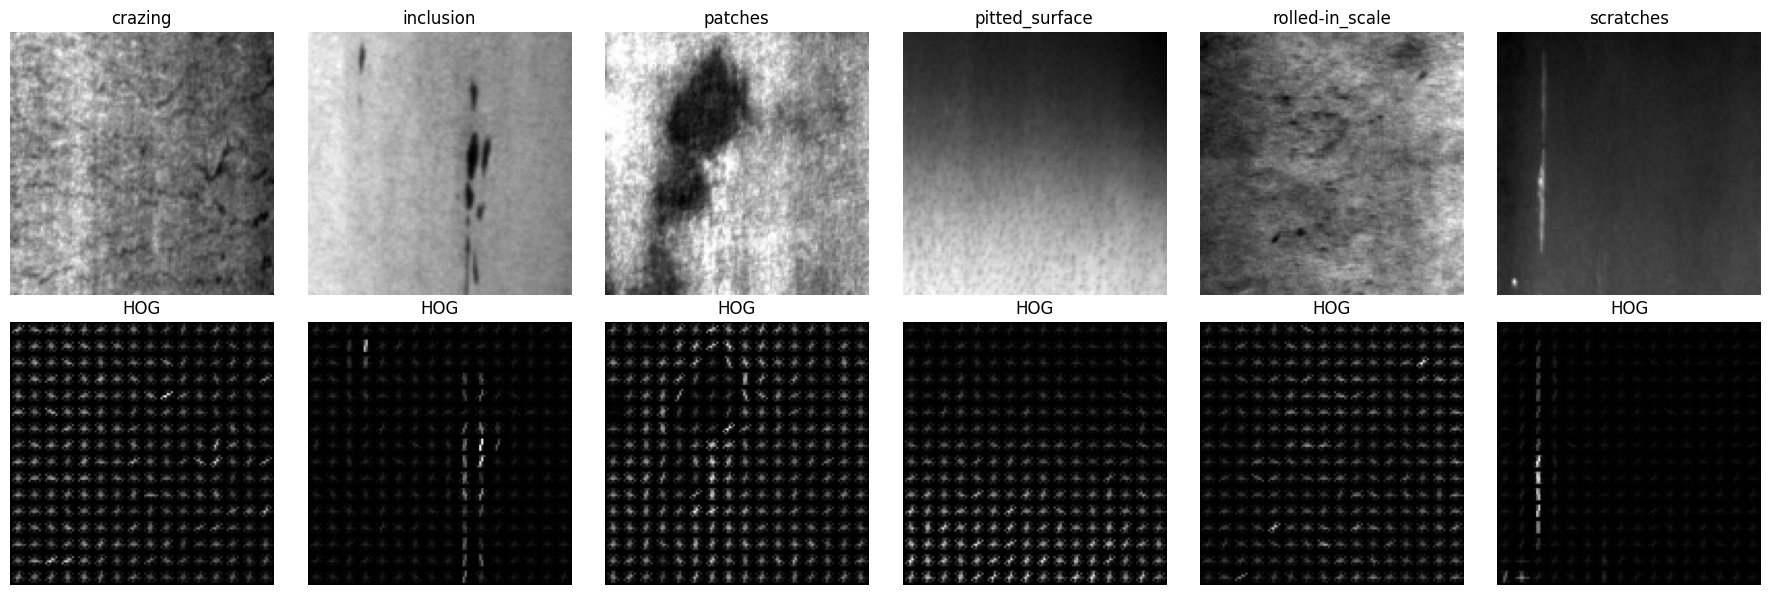

In [6]:
show = classes[:6]
fig, ax = plt.subplots(2, len(show), figsize=(3*len(show), 6), squeeze=False)
for j, c in enumerate(show):
    i = np.where(y_raw == c)[0][0]
    _, vis = hog(G[i], orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2), visualize=True)
    ax[0,j].imshow(G[i], cmap="gray"); ax[0,j].set_title(c); ax[0,j].axis("off")
    ax[1,j].imshow(vis, cmap="gray");  ax[1,j].set_title("HOG"); ax[1,j].axis("off")
plt.tight_layout(); plt.savefig(f"{OUT}/hog_visualisation.png", dpi=150); plt.show()

## Step 4: Train SVM + Random Forest and compare (Tasks 6–10)
Baseline HOG setting: 8×8 cells, 9 orientations.


=== HOG+SVM (RBF) ===
                  precision    recall  f1-score   support

        crazing       0.85      1.00      0.92        45
      inclusion       0.85      0.91      0.88        45
        patches       0.79      0.82      0.80        45
 pitted_surface       0.85      0.62      0.72        45
rolled-in_scale       0.98      1.00      0.99        45
      scratches       0.95      0.91      0.93        45

       accuracy                           0.88       270
      macro avg       0.88      0.88      0.87       270
   weighted avg       0.88      0.88      0.87       270



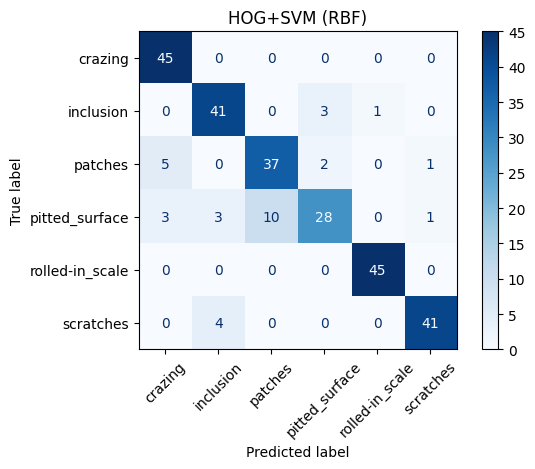


=== HOG+RandomForest ===
                  precision    recall  f1-score   support

        crazing       0.70      0.98      0.81        45
      inclusion       0.71      0.91      0.80        45
        patches       0.71      0.53      0.61        45
 pitted_surface       0.68      0.56      0.61        45
rolled-in_scale       0.92      1.00      0.96        45
      scratches       0.97      0.62      0.76        45

       accuracy                           0.77       270
      macro avg       0.78      0.77      0.76       270
   weighted avg       0.78      0.77      0.76       270



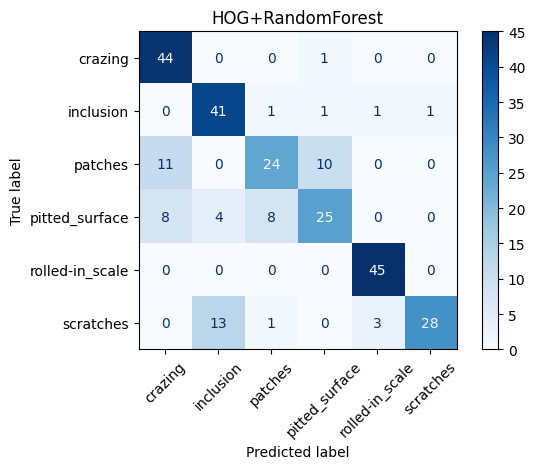

,accuracy,precision,recall,f1,model,train_s,infer_ms_per_img
0,0.8778,0.8784,0.8778,0.8739,HOG+SVM (RBF),40.7344,9.7625
1,0.7667,0.7785,0.7667,0.7571,HOG+RandomForest,18.9750,0.2567


In [7]:
Ftr, Fva, Fte = (extract(G[s]) for s in (tr, va, te))
rows = []
for name, model in make_models().items():
    t0 = time.time(); model.fit(Ftr, y_lab[tr]); t_fit = time.time()-t0
    t0 = time.time(); pred = model.predict(Fte); t_inf = (time.time()-t0)/len(te)*1000
    m = metrics(y_lab[te], pred); m.update(model=name, train_s=t_fit, infer_ms_per_img=t_inf); rows.append(m)
    print(f"\n=== {name} ===\n", classification_report(y_lab[te], pred, target_names=names, zero_division=0))
    ConfusionMatrixDisplay(confusion_matrix(y_lab[te], pred), display_labels=names).plot(xticks_rotation=45, cmap="Blues")
    plt.title(name); plt.tight_layout(); plt.savefig(f"{OUT}/cm_{name.split()[0].replace('+','_')}.png", dpi=150); plt.show()
comp = pd.DataFrame(rows); comp.to_csv(f"{OUT}/classifier_comparison.csv", index=False)
display(comp.round(4))

## Step 5: HOG parameter study (Task 11)
Cell sizes 4/8/16 × orientations 6/9/12 with the SVM. The best setting is chosen on the **validation** set (not the test set) to avoid leakage.

In [8]:
from joblib import Parallel, delayed

def extract_fast(grays, cell, ori):
    return np.array(Parallel(n_jobs=-1)(delayed(hog_feat)(g, cell, ori) for g in grays))

def fast_svm():   # no probability=True -> much faster for the grid
    return make_pipeline(StandardScaler(),
                         SVC(kernel="rbf", C=10, gamma="scale",
                             class_weight="balanced", random_state=SEED))

grid = []
for cell, ori in itertools.product([4, 8, 16], [6, 9, 12]):
    t0 = time.time()
    A, V, B = (extract_fast(G[s], cell, ori) for s in (tr, va, te))
    t_ext = (time.time()-t0)/(len(tr)+len(va)+len(te))*1000
    mdl = fast_svm().fit(A, y_lab[tr])
    m = metrics(y_lab[te], mdl.predict(B))
    m.update(cell=cell, orientations=ori, feat_dim=A.shape[1], extract_ms_per_img=t_ext,
             val_f1=metrics(y_lab[va], mdl.predict(V))["f1"])
    grid.append(m)
    print(f"cell {cell:>2} ori {ori:>2} | dim {A.shape[1]:>6} | test acc {m['accuracy']:.4f} "
          f"| test F1 {m['f1']:.4f} | {time.time()-t0:.0f}s")

gdf = pd.DataFrame(grid); gdf.to_csv(f"{OUT}/hog_parameter_study.csv", index=False)
display(gdf.round(4))

best = gdf.sort_values("val_f1", ascending=False).iloc[0]   # chosen on VALIDATION
bc, bo = int(best.cell), int(best.orientations)
print(f"Best HOG setting (validation F1): cell={bc}, orientations={bo}")

# final model (train+val) with the best setting; probability=True so confidence works
trva = np.concatenate([tr, va])
final = make_models()["HOG+SVM (RBF)"].fit(extract_fast(G[trva], bc, bo), y_lab[trva])
bundle = dict(model=final, cell=bc, ori=bo, names=names, binary=(names[0] == "NON-DEFECTIVE"))
joblib.dump(bundle, f"{OUT}/final_model.joblib")

cell  4 ori  6 | dim  23064 | test acc 0.8037 | test F1 0.7976 | 106s
cell  4 ori  9 | dim  34596 | test acc 0.7852 | test F1 0.7757 | 136s
cell  4 ori 12 | dim  46128 | test acc 0.8000 | test F1 0.7933 | 176s
cell  8 ori  6 | dim   5400 | test acc 0.8852 | test F1 0.8818 | 17s
cell  8 ori  9 | dim   8100 | test acc 0.8778 | test F1 0.8739 | 22s
cell  8 ori 12 | dim  10800 | test acc 0.8778 | test F1 0.8754 | 34s
cell 16 ori  6 | dim   1176 | test acc 0.9185 | test F1 0.9173 | 4s
cell 16 ori  9 | dim   1764 | test acc 0.9185 | test F1 0.9172 | 6s
cell 16 ori 12 | dim   2352 | test acc 0.9296 | test F1 0.9292 | 7s


,accuracy,precision,recall,f1,cell,orientations,feat_dim,extract_ms_per_img,val_f1
0,0.8037,0.8076,0.8037,0.7976,4,6,23064,21.7354,0.8544
1,0.7852,0.7901,0.7852,0.7757,4,9,34596,21.5388,0.8149
2,0.8000,0.8102,0.8000,0.7933,4,12,46128,21.6687,0.8391
3,0.8852,0.8888,0.8852,0.8818,8,6,5400,5.7014,0.8955
4,0.8778,0.8784,0.8778,0.8739,8,9,8100,5.5076,0.8843
5,0.8778,0.8812,0.8778,0.8754,8,12,10800,6.2945,0.9112
6,0.9185,0.9182,0.9185,0.9173,16,6,1176,1.9883,0.9105
7,0.9185,0.9183,0.9185,0.9172,16,9,1764,2.2027,0.9182
8,0.9296,0.9300,0.9296,0.9292,16,12,2352,2.6734,0.9443


Best HOG setting (validation F1): cell=16, orientations=12


['lab05_output/final_model.joblib']

## Step 6: Robustness test (Task 12)
Model trained on clean images, tested on brightness change, Gaussian noise, rotation and blur.

,condition,accuracy,precision,recall,f1,d_acc,d_f1
0,clean,0.9259,0.9259,0.9259,0.9249,0.0000,0.0000
1,brightness +40,0.8333,0.8653,0.8333,0.8313,-0.0926,-0.0936
2,brightness -40,0.9148,0.9176,0.9148,0.9130,-0.0111,-0.0119
3,gaussian noise s=15,0.2259,0.1940,0.2259,0.1400,-0.7000,-0.7849
4,rotation 15deg,0.8815,0.8917,0.8815,0.8812,-0.0444,-0.0437
5,blur 5x5,0.5000,0.6392,0.5000,0.4888,-0.4259,-0.4361


Binomial SE of accuracy ~ 1.59 pts; differences under ~3.2 pts are not meaningful (single run).


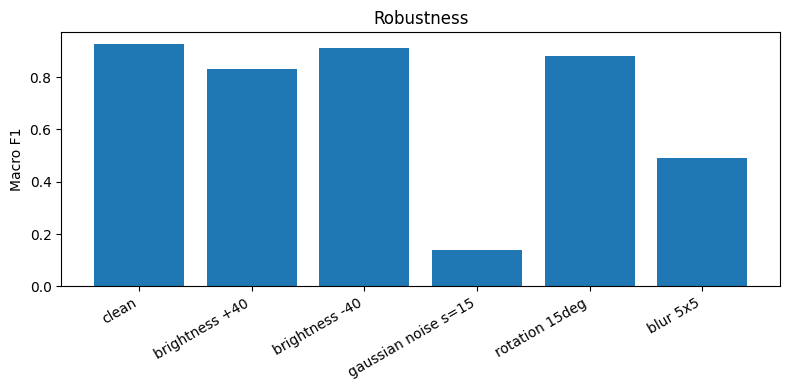

In [9]:
base = metrics(y_lab[te], final.predict(extract(G[te], bc, bo)))
rob = [dict(condition="clean", **base, d_acc=0.0, d_f1=0.0)]
tests = {"brightness +40": brightness, "brightness -40": lambda g: brightness(g, -40),
         "gaussian noise s=15": noise, "rotation 15deg": rotate, "blur 5x5": blur}
for k, fn in tests.items():
    m = metrics(y_lab[te], final.predict(extract(np.array([fn(g) for g in G[te]]), bc, bo)))
    rob.append(dict(condition=k, **m, d_acc=m["accuracy"]-base["accuracy"], d_f1=m["f1"]-base["f1"]))
rdf = pd.DataFrame(rob); rdf.to_csv(f"{OUT}/robustness.csv", index=False); display(rdf.round(4))

se = np.sqrt(base["accuracy"]*(1-base["accuracy"])/len(te))*100
print(f"Binomial SE of accuracy ~ {se:.2f} pts; differences under ~{2*se:.1f} pts are not meaningful (single run).")

plt.figure(figsize=(8,4)); plt.bar(rdf.condition, rdf.f1); plt.xticks(rotation=30, ha="right")
plt.ylabel("Macro F1"); plt.title("Robustness"); plt.tight_layout()
plt.savefig(f"{OUT}/robustness.png", dpi=150); plt.show()

## Step 7: Final inspection decision module (Task 13)

In [10]:
for i in np.random.default_rng(1).choice(te, 3, replace=False):
    print("True label:", y_raw[i])
    inspect_image(X_raw[i], bundle); print("-"*35)

True label: pitted_surface
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (pitted_surface)
Confidence: 95.5%
Action: REJECT PRODUCT
-----------------------------------
True label: inclusion
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (inclusion)
Confidence: 95.3%
Action: REJECT PRODUCT
-----------------------------------
True label: crazing
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (crazing)
Confidence: 99.6%
Action: REJECT PRODUCT
-----------------------------------


## Step 8: Download all results (figures, tables, model)

In [13]:
!zip -qr lab05_output.zip lab05_output
from google.colab import files
files.download("lab05_output.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>